# Import example subject behavioral data

This notebook loads behavioral and stimulus-sequence `.mat` files for one example subject from `data/raw/`, ignoring the eyetracking files. It creates:

- `trials_df`: one row per behavioral trial
- `samples_df`: one row per sample within each trial
- `block_metadata_df`: one row per block with values that do not vary trial-to-trial

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio

In [2]:
DATA_ROOT = Path("data/Murphy2021/raw")
if not DATA_ROOT.exists():
    DATA_ROOT = Path("~/Documents/academic/data/Murphy2021/raw").expanduser()
EXAMPLE_SUBJECT = "DCB"
INCLUDE_TRAINING = False

subject_dir = DATA_ROOT / EXAMPLE_SUBJECT
subject_dir

PosixPath('data/Murphy2021/raw/DCB')

In [3]:
def load_mat(path):
    """Load a MATLAB .mat file and drop scipy's private metadata keys."""
    mat = sio.loadmat(path, squeeze_me=True, struct_as_record=False)
    return {key: value for key, value in mat.items() if not key.startswith("__")}


def matlab_value_to_python(value):
    """Convert MATLAB scalar/array/struct values into notebook-friendly Python objects."""
    if hasattr(value, "_fieldnames"):
        return {field: matlab_value_to_python(getattr(value, field)) for field in value._fieldnames}

    if isinstance(value, np.ndarray):
        if value.ndim == 0:
            return matlab_value_to_python(value.item())
        return value.tolist()

    if isinstance(value, np.generic):
        return value.item()

    return value


def flatten_dict(d, prefix=""):
    """Flatten nested metadata dictionaries into dot-separated columns."""
    rows = {}
    for key, value in d.items():
        name = f"{prefix}.{key}" if prefix else key
        if isinstance(value, dict):
            rows.update(flatten_dict(value, name))
        else:
            rows[name] = value
    return rows


def parse_subject_session_block(path):
    """Read participant/session/block from file names like DCB_1_1.mat."""
    parts = path.stem.split("_")
    block = int(parts[-1])
    session_number = int(parts[-2])
    participant_id = "_".join(parts[:-2])
    return participant_id, session_number, block

In [4]:
session_dirs = sorted(
    path
    for path in subject_dir.iterdir()
    if path.is_dir() and (INCLUDE_TRAINING or path.name != "Training")
)

session_dirs

[PosixPath('data/Murphy2021/raw/DCB/S1'),
 PosixPath('data/Murphy2021/raw/DCB/S2'),
 PosixPath('data/Murphy2021/raw/DCB/S3')]

In [5]:
behav_columns = [
    "correct_response_dist",
    "response",
    "accuracy",
    "rt_from_go_cue",
    "trial_onset_ptb",
    "fixation_break_count",
]

trial_frames = []
sample_frames = []
block_metadata_rows = []

for session_dir in session_dirs:
    behaviour_dir = session_dir / "Behaviour"
    sample_seqs_dir = session_dir / "Sample_seqs"

    for behav_path in sorted(behaviour_dir.glob("*.mat")):
        sample_path = sample_seqs_dir / behav_path.name
        if not sample_path.exists():
            raise FileNotFoundError(f"Missing matching Sample_seqs file for {behav_path}")

        participant_id, session_number, block = parse_subject_session_block(behav_path)
        block_id = f"{participant_id}_S{session_number}_B{block}"

        behav_mat = load_mat(behav_path)
        sample_mat = load_mat(sample_path)

        behav = np.asarray(behav_mat["Behav"])
        t_refresh = np.asarray(behav_mat["tRefresh"])
        stim_in = np.asarray(sample_mat["stimIn"])
        distseqs = np.asarray(sample_mat["distseqs"])
        pswitch = np.asarray(sample_mat["pswitch"])

        if behav.ndim != 2 or behav.shape[1] != len(behav_columns):
            raise ValueError(f"Unexpected Behav shape in {behav_path}: {behav.shape}")

        n_planned_trials, n_samples = stim_in.shape
        n_trials = behav.shape[0]
        if n_trials > n_planned_trials:
            raise ValueError(
                f"More behavioral trials than stimulus rows for {block_id}: "
                f"Behav has {n_trials}, stimIn has {n_planned_trials}"
            )

        # Some blocks can be interrupted. Keep only rows with completed behavior
        # in the trial- and sample-level dataframes, and record the mismatch below.
        stim_in_completed = stim_in[:n_trials]
        distseqs_completed = distseqs[:n_trials]
        pswitch_completed = pswitch[:n_trials]
        t_refresh_completed = t_refresh[:n_trials]

        trial_df = pd.DataFrame(behav, columns=behav_columns)
        trial_df.insert(0, "trial", np.arange(1, n_trials + 1))
        trial_df.insert(0, "block", block)
        trial_df.insert(0, "session", session_number)
        trial_df.insert(0, "session_label", session_dir.name)
        trial_df.insert(0, "participant_id", participant_id)
        trial_df.insert(0, "subject_folder", subject_dir.name)
        trial_df.insert(0, "block_id", block_id)

        trial_df["n_presented_samples"] = np.sum(~np.isnan(stim_in_completed), axis=1)
        trial_df["final_sample_location"] = stim_in_completed[
            np.arange(n_trials), trial_df["n_presented_samples"].to_numpy() - 1
        ]
        trial_frames.append(trial_df)

        sample_df = pd.DataFrame(
            {
                "block_id": np.repeat(block_id, n_trials * n_samples),
                "subject_folder": np.repeat(subject_dir.name, n_trials * n_samples),
                "participant_id": np.repeat(participant_id, n_trials * n_samples),
                "session_label": np.repeat(session_dir.name, n_trials * n_samples),
                "session": np.repeat(session_number, n_trials * n_samples),
                "block": np.repeat(block, n_trials * n_samples),
                "trial": np.repeat(np.arange(1, n_trials + 1), n_samples),
                "sample": np.tile(np.arange(1, n_samples + 1), n_trials),
                "stim_location_deg": stim_in_completed.reshape(-1),
                "generative_dist": distseqs_completed.reshape(-1),
                "distribution_switch": pswitch_completed.reshape(-1),
                "sample_onset_from_trial_s": t_refresh_completed.reshape(-1),
            }
        )
        sample_frames.append(sample_df)

        metadata = {
            "block_id": block_id,
            "subject_folder": subject_dir.name,
            "participant_id": participant_id,
            "session_label": session_dir.name,
            "session": session_number,
            "block": block,
            "n_completed_trials": n_trials,
            "n_planned_trials": n_planned_trials,
            "has_incomplete_behaviour": n_trials != n_planned_trials,
            "n_samples": n_samples,
            "behaviour_file": str(behav_path),
            "sample_seqs_file": str(sample_path),
            "pshort": matlab_value_to_python(sample_mat["pshort"]),
        }
        for struct_name in ["gen", "timing", "stim"]:
            metadata.update(
                flatten_dict({struct_name: matlab_value_to_python(sample_mat[struct_name])})
            )
        block_metadata_rows.append(metadata)

trials_df = pd.concat(trial_frames, ignore_index=True)
samples_df = pd.concat(sample_frames, ignore_index=True)
block_metadata_df = pd.DataFrame(block_metadata_rows)

trials_df.shape, samples_df.shape, block_metadata_df.shape

((2005, 15), (24060, 12), (27, 58))

In [6]:
trials_df.head()

,block_id,subject_folder,participant_id,session_label,session,block,trial,correct_response_dist,response,accuracy,rt_from_go_cue,trial_onset_ptb,fixation_break_count,n_presented_samples,final_sample_location
0,DCB_S1_B1,DCB,DCB,S1,1,1,1,1.0,1.0,1.0,1.515773,1.497944e+09,0.0,8,19.0
1,DCB_S1_B1,DCB,DCB,S1,1,1,2,2.0,2.0,1.0,0.007256,1.497944e+09,0.0,12,4.0
2,DCB_S1_B1,DCB,DCB,S1,1,1,3,2.0,1.0,0.0,0.006124,1.497944e+09,0.0,12,11.0
3,DCB_S1_B1,DCB,DCB,S1,1,1,4,1.0,1.0,1.0,0.006226,1.497944e+09,0.0,12,29.0
4,DCB_S1_B1,DCB,DCB,S1,1,1,5,1.0,1.0,1.0,0.006103,1.497944e+09,0.0,4,47.0


In [7]:
samples_df.head(15)

,block_id,subject_folder,participant_id,session_label,session,block,trial,sample,stim_location_deg,generative_dist,distribution_switch,sample_onset_from_trial_s
0,DCB_S1_B1,DCB,DCB,S1,1,1,1,1,61.0,1.0,0.0,0.399993
1,DCB_S1_B1,DCB,DCB,S1,1,1,1,2,-38.0,1.0,0.0,0.799975
2,DCB_S1_B1,DCB,DCB,S1,1,1,1,3,81.0,1.0,0.0,1.199959
3,DCB_S1_B1,DCB,DCB,S1,1,1,1,4,7.0,1.0,0.0,1.599944
4,DCB_S1_B1,DCB,DCB,S1,1,1,1,5,-37.0,1.0,0.0,1.999933
5,DCB_S1_B1,DCB,DCB,S1,1,1,1,6,28.0,1.0,0.0,2.399927
6,DCB_S1_B1,DCB,DCB,S1,1,1,1,7,20.0,1.0,0.0,2.799911
7,DCB_S1_B1,DCB,DCB,S1,1,1,1,8,19.0,1.0,0.0,3.199891
8,DCB_S1_B1,DCB,DCB,S1,1,1,1,9,NaN,NaN,NaN,0.000000
9,DCB_S1_B1,DCB,DCB,S1,1,1,1,10,NaN,NaN,NaN,0.000000


In [38]:
samples_df.loc[samples_df['stim_location_deg']==-89.99,'stim_location_deg'] = -90.0
samples_df.loc[samples_df['stim_location_deg']==89.99,'stim_location_deg'] = 90.0

In [48]:
from scipy.stats import norm

mean_neg, mean_pos = -17, 17
std = 29

dist_neg = norm(loc=mean_neg, scale=std)
dist_pos = norm(loc=mean_pos, scale=std)

samples_df['LLR_pos'] = np.log(dist_pos.pdf(samples_df['stim_location_deg']) / dist_neg.pdf(samples_df['stim_location_deg']))
samples_df.head(15)

,block_id,subject_folder,participant_id,session_label,session,block,trial,sample,stim_location_deg,generative_dist,distribution_switch,sample_onset_from_trial_s,LLR_pos
0,DCB_S1_B1,DCB,DCB,S1,1,1,1,1,61.0,1.0,0.0,0.399993,2.466112
1,DCB_S1_B1,DCB,DCB,S1,1,1,1,2,-38.0,1.0,0.0,0.799975,-1.536266
2,DCB_S1_B1,DCB,DCB,S1,1,1,1,3,81.0,1.0,0.0,1.199959,3.274673
3,DCB_S1_B1,DCB,DCB,S1,1,1,1,4,7.0,1.0,0.0,1.599944,0.282996
4,DCB_S1_B1,DCB,DCB,S1,1,1,1,5,-37.0,1.0,0.0,1.999933,-1.495838
5,DCB_S1_B1,DCB,DCB,S1,1,1,1,6,28.0,1.0,0.0,2.399927,1.131986
6,DCB_S1_B1,DCB,DCB,S1,1,1,1,7,20.0,1.0,0.0,2.799911,0.808561
7,DCB_S1_B1,DCB,DCB,S1,1,1,1,8,19.0,1.0,0.0,3.199891,0.768133
8,DCB_S1_B1,DCB,DCB,S1,1,1,1,9,NaN,NaN,NaN,0.000000,NaN
9,DCB_S1_B1,DCB,DCB,S1,1,1,1,10,NaN,NaN,NaN,0.000000,NaN


In [8]:
block_metadata_df.head()

,block_id,subject_folder,participant_id,session_label,session,block,n_completed_trials,n_planned_trials,has_incomplete_behaviour,n_samples,...,stim.audio.device.NrOutputChannels,stim.audio.device.LowInputLatency,stim.audio.device.HighInputLatency,stim.audio.device.LowOutputLatency,stim.audio.device.HighOutputLatency,stim.audio.device.DefaultSampleRate,stim.audio.h,stim.audio.tonebuf,stim.audio.tonepos,stim.cbartex
0,DCB_S1_B1,DCB,DCB,S1,1,1,76,76,False,12,...,128,0.01161,0.04644,0.01161,0.04644,44100,0,"[[0.0, 0.00044548156986781365, 0.0009088281626...","[[0, 5512], [5513, 11025], [11026, 22051]]",13
1,DCB_S1_B2,DCB,DCB,S1,1,2,76,76,False,12,...,128,0.01161,0.04644,0.01161,0.04644,44100,0,"[[0.0, 0.00044548156986781365, 0.0009088281626...","[[0, 5512], [5513, 11025], [11026, 22051]]",13
2,DCB_S1_B3,DCB,DCB,S1,1,3,76,76,False,12,...,128,0.01161,0.04644,0.01161,0.04644,44100,0,"[[0.0, 0.00044548156986781365, 0.0009088281626...","[[0, 5512], [5513, 11025], [11026, 22051]]",13
3,DCB_S1_B4,DCB,DCB,S1,1,4,76,76,False,12,...,128,0.01161,0.04644,0.01161,0.04644,44100,0,"[[0.0, 0.00044548156986781365, 0.0009088281626...","[[0, 5512], [5513, 11025], [11026, 22051]]",13
4,DCB_S1_B5,DCB,DCB,S1,1,5,76,76,False,12,...,128,0.01161,0.04644,0.01161,0.04644,44100,0,"[[0.0, 0.00044548156986781365, 0.0009088281626...","[[0, 5512], [5513, 11025], [11026, 22051]]",13


In [9]:
trials_df.groupby(["session_label", "block"]).agg(
    n_trials=("trial", "size"),
    accuracy=("accuracy", "mean"),
    median_rt=("rt_from_go_cue", "median"),
    mean_presented_samples=("n_presented_samples", "mean"),
)

n_trials  accuracy  median_rt  mean_presented_samples
session_label block                                                       
S1            1            76  0.736842   0.006155               10.592105
              2            76  0.776316   0.006148               10.697368
              3            76  0.789474   0.006147               10.789474
              4            76  0.789474   0.006133               10.789474
              5            76  0.789474   0.006121               10.486842
              6            76  0.723684   0.006130               10.855263
              7            76  0.750000   0.006108               10.605263
              8            76  0.815789   0.006128               10.513158
              9            29  0.620690   0.006115               10.551724
S2            1            76  0.697368   0.006124               10.657895
              2            76  0.736842   0.006110               10.565789
              3            76  0.868421   0.006110               10.789474
              4            76  0.750000   0.006109               10.342105
              5            76  0.842105   0.006101               10.855263
              6            76  0.802632   0.006169               10.513158
              7            76  0.842105   0.006156               10.618421
              8            76  0.763158   0.006162               10.802632
              9            76  0.802632   0.006139               10.578947
S3            1            76  0.789474   0.006131               10.355263
              2            76  0.736842   0.006137               10.644737
              3            76  0.802632   0.006135               10.855263
              4            76  0.776316   0.006116               10.802632
              5            76  0.894737   0.006128               10.447368
              6            76  0.763158   0.006121               10.894737
              7            76  0.855263   0.006111               10.578947
              8            76  0.671053   0.006117               10.671053
              9            76  0.828947   0.006103               10.578947

In [10]:
block_metadata_df['n_completed_trials'].sum(), block_metadata_df['n_planned_trials'].sum()

(2005, 2052)

In [52]:
samples_arr_by_trial = (
    samples_df.sort_values("sample")
    .groupby(["session", "block", "trial"])["stim_location_deg"]
    .apply(lambda s: s.dropna().to_numpy())
)

trials_df["samples_arr"] = pd.MultiIndex.from_frame(
    trials_df[["session", "block", "trial"]]
).map(samples_arr_by_trial)

llr_arr_by_trial = (
    samples_df.sort_values("sample")
    .groupby(["session", "block", "trial"])["LLR_pos"]
    .apply(lambda s: s.dropna().to_numpy())
)

trials_df["LLR_arr"] = pd.MultiIndex.from_frame(
    trials_df[["session", "block", "trial"]]
).map(llr_arr_by_trial)

trials_df[["session", "block", "trial", "n_presented_samples", "samples_arr", "LLR_arr"]].head()

,session,block,trial,n_presented_samples,samples_arr,LLR_arr
0,1,1,1,8,"[61.0, -38.0, 81.0, 7.0, -37.0, 28.0, 20.0, 19.0]","[2.466111771700357, -1.5362663495838287, 3.274..."
1,1,1,2,12,"[-67.0, -35.0, -8.0, -34.0, -61.0, 6.0, -29.0,...","[-2.7086801426872777, -1.4149821640903688, -0...."
2,1,1,3,12,"[23.0, -25.0, -17.0, -25.0, 5.0, 1.0, -5.0, -2...","[0.9298454221165282, -1.0107015457788346, -0.6..."
3,1,1,4,12,"[-1.0, 67.0, -14.0, 0.0, 9.0, -10.0, 50.0, -32...","[-0.04042806183115348, 2.7086801426872777, -0...."
4,1,1,5,4,"[56.0, 5.0, 48.0, 47.0]","[2.2639714625445895, 0.202140309155767, 1.9405..."


In [91]:
def P_source_g_samples(samples_arr,mean_neg,mean_pos,std,h,P0,window_size=None):
    P_sample_g_neg = norm(loc=mean_neg, scale=std)
    P_sample_g_pos = norm(loc=mean_pos, scale=std)
    Lneg = P_sample_g_neg.pdf(samples_arr)
    Lpos = P_sample_g_pos.pdf(samples_arr)
    L = np.stack((Lneg,Lpos),axis=1).T
    H = np.array([
        [1-h, h],
        [h, 1-h]
    ])
    P = P0.copy()
    if window_size is not None:
        L = L[:,-window_size:]
    for ii in range(L.shape[1]):
        P = L[:,ii][:,np.newaxis] * (H @ P)
    P = P / P.sum(axis=0,keepdims=True)
    return P

In [99]:
h_col_candidates = [c for c in ["gen.h", "gen.H", "h", "H"] if c in block_metadata_df.columns]
if h_col_candidates:
    h_col = h_col_candidates[0]
else:
    h_like_cols = [c for c in block_metadata_df.columns if c.lower().endswith(".h") or c.lower() == "h"]
    if len(h_like_cols) != 1:
        raise KeyError(f"Could not uniquely identify hazard-rate column in block_metadata_df. Candidates: {h_like_cols}")
    h_col = h_like_cols[0]

h_by_block = block_metadata_df.set_index("block_id")[h_col]
P0 = np.array([[0.5], [0.5]])

trials_df["post_prob_pos"] = trials_df.apply(
    lambda row: float(
        P_source_g_samples(
            np.asarray(row["samples_arr"], dtype=float),
            mean_neg,
            mean_pos,
            std,
            float(h_by_block.loc[row["block_id"]]),
            P0,
        )[1, 0]
    ),
    axis=1,
)

trials_df["post_prob_1b_pos"] = trials_df.apply(
    lambda row: float(
        P_source_g_samples(
            np.asarray(row["samples_arr"], dtype=float),
            mean_neg,
            mean_pos,
            std,
            float(h_by_block.loc[row["block_id"]]),
            P0,
            window_size=1
        )[1, 0]
    ),
    axis=1,
)

trials_df[["block_id", "trial", "post_prob_pos", "post_prob_1b_pos"]].head()

,block_id,trial,post_prob_pos,post_prob_1b_pos
0,DCB_S1_B1,1,0.901507,0.683117
1,DCB_S1_B1,2,0.214954,0.540340
2,DCB_S1_B1,3,0.294163,0.609380
3,DCB_S1_B1,4,0.891987,0.763581
4,DCB_S1_B1,5,0.982251,0.869905


In [129]:
def psychometric_choice_probability(
    trials_df,
    variable,
    block_metadata_df=None,
    block_conditions=None,
    bins=None,
    n_bins=10,
    response_col="response",
    block_id_col="block_id",
    return_bins=False,
):
    """Estimate P(choose positive source) as a function of a binned variable.

    Positive-source choices are expected to be encoded as response == 1.

    Parameters
    ----------
    trials_df : pandas.DataFrame
        Trial-level dataframe.
    variable : str or array-like
        Continuous trial-level variable to bin, e.g. "post_prob_pos". If an
        array is passed, it must have the same length as `trials_df`.
    block_metadata_df : pandas.DataFrame, optional
        Block-level metadata dataframe used when `block_conditions` is given.
    block_conditions : callable, pandas.Series, array-like, or dict, optional
        Conditions evaluated on `block_metadata_df`. A callable should take
        `block_metadata_df` and return a boolean mask. A dict maps column names
        to allowed values, iterables of allowed values, or callables evaluated
        on the column.
    bins : int or array-like, optional
        Number of equal-width bins or explicit bin edges. If omitted, `n_bins`
        equal-width bins spanning the observed values are used.
    n_bins : int, default 10
        Number of bins to use when `bins` is not provided.
    response_col : str, default "response"
        Trial-level response column, where positive-source choices are 1.
    block_id_col : str, default "block_id"
        Shared block identifier column in `trials_df` and `block_metadata_df`.
    return_bins : bool, default False
        If True, also return the bin edges actually used.

    Returns
    -------
    bin_centers : numpy.ndarray
        Centers of the bins.
    choice_probabilities : numpy.ndarray
        Mean probability of response == 1 in each bin. Empty bins are NaN.
    bins : numpy.ndarray, optional
        Returned only when `return_bins=True`.
    """
    trial_data = trials_df.copy()

    if isinstance(variable, str):
        if variable not in trial_data.columns:
            raise KeyError(f"{variable!r} is not a column in trials_df")
        variable_values = trial_data[variable].to_numpy(dtype=float)
    else:
        variable_values = np.asarray(variable, dtype=float)
        if variable_values.shape[0] != len(trial_data):
            raise ValueError("array-like `variable` must have one value per row in trials_df")

    if response_col not in trial_data.columns:
        raise KeyError(f"{response_col!r} is not a column in trials_df")

    if block_conditions is not None:
        if block_metadata_df is None:
            raise ValueError("block_metadata_df is required when block_conditions is provided")
        if block_id_col not in trial_data.columns or block_id_col not in block_metadata_df.columns:
            raise KeyError(f"{block_id_col!r} must be present in trials_df and block_metadata_df")

        if callable(block_conditions):
            block_mask = block_conditions(block_metadata_df)
        elif isinstance(block_conditions, dict):
            block_mask = pd.Series(True, index=block_metadata_df.index)
            for column, condition in block_conditions.items():
                if column not in block_metadata_df.columns:
                    raise KeyError(f"{column!r} is not a column in block_metadata_df")
                values = block_metadata_df[column]
                if callable(condition):
                    condition_mask = condition(values)
                elif isinstance(condition, (list, tuple, set, np.ndarray, pd.Index)):
                    condition_mask = values.isin(condition)
                else:
                    condition_mask = values == condition
                block_mask &= pd.Series(condition_mask, index=block_metadata_df.index).astype(bool)
        else:
            block_mask = pd.Series(block_conditions, index=block_metadata_df.index).astype(bool)

        included_blocks = block_metadata_df.loc[block_mask, block_id_col]
        trial_mask = trial_data[block_id_col].isin(included_blocks)
        trial_data = trial_data.loc[trial_mask]
        variable_values = variable_values[trial_mask.to_numpy()]

    responses = trial_data[response_col].to_numpy(dtype=float)
    finite_mask = np.isfinite(variable_values) & np.isfinite(responses)
    variable_values = variable_values[finite_mask]
    responses = responses[finite_mask]

    if variable_values.size == 0:
        raise ValueError("No finite trials remain after applying filters")

    if bins is None:
        lo, hi = np.nanmin(variable_values), np.nanmax(variable_values)
        if lo == hi:
            half_width = 0.5 if lo == 0 else abs(lo) * 0.05
            lo, hi = lo - half_width, hi + half_width
        bins = np.linspace(lo, hi, n_bins + 1)
    elif np.isscalar(bins):
        lo, hi = np.nanmin(variable_values), np.nanmax(variable_values)
        if lo == hi:
            half_width = 0.5 if lo == 0 else abs(lo) * 0.05
            lo, hi = lo - half_width, hi + half_width
        bins = np.linspace(lo, hi, int(bins) + 1)
    else:
        bins = np.asarray(bins, dtype=float)

    if bins.ndim != 1 or bins.size < 2 or np.any(np.diff(bins) <= 0):
        raise ValueError("bins must be increasing bin edges or a positive integer")

    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_index = np.digitize(variable_values, bins, right=False) - 1
    bin_index[variable_values == bins[-1]] = len(bins) - 2

    choice_probabilities = np.full(len(bin_centers), np.nan)
    for idx in range(len(bin_centers)):
        in_bin = bin_index == idx
        if np.any(in_bin):
            choice_probabilities[idx] = np.mean(responses[in_bin] == 1)

    if return_bins:
        return bin_centers, choice_probabilities, bins
    return bin_centers, choice_probabilities

def psychometric_choice_probability_2d(
    trials_df,
    variables,
    block_metadata_df=None,
    block_conditions=None,
    bins=None,
    n_bins=10,
    response_col="response",
    block_id_col="block_id",
    return_flat=False,
    return_bins=False,
):
    """Estimate P(choose positive source) in bins of two continuous variables.

    Positive-source choices are expected to be encoded as response == 1.

    Parameters
    ----------
    trials_df : pandas.DataFrame
        Trial-level dataframe.
    variables : sequence of two str or array-like
        Continuous trial-level variables to bin, e.g. ("post_prob_pos",
        "post_prob_1b_pos"). Array-like values must have one value per row in
        `trials_df`.
    block_metadata_df : pandas.DataFrame, optional
        Block-level metadata dataframe used when `block_conditions` is given.
    block_conditions : callable, pandas.Series, array-like, or dict, optional
        Conditions evaluated on `block_metadata_df`, with the same conventions
        as `psychometric_choice_probability`.
    bins : int, array-like, or sequence of two, optional
        Bin definition for the two variables. Use one integer for the same
        number of inferred bins along both dimensions, one array of edges for
        both dimensions, or a two-item sequence with separate definitions for
        each dimension. If omitted, `n_bins` inferred bins are used.
    n_bins : int or sequence of two int, default 10
        Number of bins to use when `bins` is not provided.
    response_col : str, default "response"
        Trial-level response column, where positive-source choices are 1.
    block_id_col : str, default "block_id"
        Shared block identifier column in `trials_df` and `block_metadata_df`.
    return_flat : bool, default False
        If False, return a grid of bin-center pairs and a grid of choice
        probabilities. If True, return unique one-dimensional bin codes and
        matching one-dimensional choice probabilities.
    return_bins : bool, default False
        If True, also return the x- and y-dimension bin edges actually used.

    Returns
    -------
    bin_centers : numpy.ndarray
        If `return_flat=False`, array with shape (n_x_bins, n_y_bins, 2), where
        the last dimension stores the x and y bin centers.
    choice_probabilities : numpy.ndarray
        If `return_flat=False`, array with shape (n_x_bins, n_y_bins). Empty
        bins are NaN.
    bin_codes : numpy.ndarray
        If `return_flat=True`, unique integer codes for each two-dimensional bin.
    choice_probabilities_flat : numpy.ndarray
        If `return_flat=True`, choice probabilities corresponding to `bin_codes`.
    x_bins, y_bins : numpy.ndarray, optional
        Returned only when `return_bins=True`.
    """
    if len(variables) != 2:
        raise ValueError("variables must contain exactly two entries")

    trial_data = trials_df.copy()
    variable_values = []
    for variable in variables:
        if isinstance(variable, str):
            if variable not in trial_data.columns:
                raise KeyError(f"{variable!r} is not a column in trials_df")
            values = trial_data[variable].to_numpy(dtype=float)
        else:
            values = np.asarray(variable, dtype=float)
            if values.shape[0] != len(trial_data):
                raise ValueError("array-like entries in `variables` must have one value per row in trials_df")
        variable_values.append(values)
    x_values, y_values = variable_values

    if response_col not in trial_data.columns:
        raise KeyError(f"{response_col!r} is not a column in trials_df")

    if block_conditions is not None:
        if block_metadata_df is None:
            raise ValueError("block_metadata_df is required when block_conditions is provided")
        if block_id_col not in trial_data.columns or block_id_col not in block_metadata_df.columns:
            raise KeyError(f"{block_id_col!r} must be present in trials_df and block_metadata_df")

        if callable(block_conditions):
            block_mask = block_conditions(block_metadata_df)
        elif isinstance(block_conditions, dict):
            block_mask = pd.Series(True, index=block_metadata_df.index)
            for column, condition in block_conditions.items():
                if column not in block_metadata_df.columns:
                    raise KeyError(f"{column!r} is not a column in block_metadata_df")
                values = block_metadata_df[column]
                if callable(condition):
                    condition_mask = condition(values)
                elif isinstance(condition, (list, tuple, set, np.ndarray, pd.Index)):
                    condition_mask = values.isin(condition)
                else:
                    condition_mask = values == condition
                block_mask &= pd.Series(condition_mask, index=block_metadata_df.index).astype(bool)
        else:
            block_mask = pd.Series(block_conditions, index=block_metadata_df.index).astype(bool)

        included_blocks = block_metadata_df.loc[block_mask, block_id_col]
        trial_mask = trial_data[block_id_col].isin(included_blocks)
        trial_data = trial_data.loc[trial_mask]
        x_values = x_values[trial_mask.to_numpy()]
        y_values = y_values[trial_mask.to_numpy()]

    responses = trial_data[response_col].to_numpy(dtype=float)
    finite_mask = np.isfinite(x_values) & np.isfinite(y_values) & np.isfinite(responses)
    x_values = x_values[finite_mask]
    y_values = y_values[finite_mask]
    responses = responses[finite_mask]

    if x_values.size == 0:
        raise ValueError("No finite trials remain after applying filters")

    def make_bins(values, bin_spec, default_n_bins):
        if bin_spec is None:
            n = int(default_n_bins)
            lo, hi = np.nanmin(values), np.nanmax(values)
            if lo == hi:
                half_width = 0.5 if lo == 0 else abs(lo) * 0.05
                lo, hi = lo - half_width, hi + half_width
            edges = np.linspace(lo, hi, n + 1)
        elif np.isscalar(bin_spec):
            lo, hi = np.nanmin(values), np.nanmax(values)
            if lo == hi:
                half_width = 0.5 if lo == 0 else abs(lo) * 0.05
                lo, hi = lo - half_width, hi + half_width
            edges = np.linspace(lo, hi, int(bin_spec) + 1)
        else:
            edges = np.asarray(bin_spec, dtype=float)
        if edges.ndim != 1 or edges.size < 2 or np.any(np.diff(edges) <= 0):
            raise ValueError("bins must be increasing bin edges or a positive integer")
        return edges

    if bins is None:
        x_bin_spec, y_bin_spec = None, None
    elif np.isscalar(bins):
        x_bin_spec, y_bin_spec = bins, bins
    elif isinstance(bins, tuple) and len(bins) == 2:
        x_bin_spec, y_bin_spec = bins
    else:
        x_bin_spec, y_bin_spec = bins, bins

    if np.isscalar(n_bins):
        x_n_bins, y_n_bins = int(n_bins), int(n_bins)
    else:
        if len(n_bins) != 2:
            raise ValueError("n_bins must be an integer or a two-item sequence")
        x_n_bins, y_n_bins = n_bins

    x_bins = make_bins(x_values, x_bin_spec, x_n_bins)
    y_bins = make_bins(y_values, y_bin_spec, y_n_bins)
    x_centers = (x_bins[:-1] + x_bins[1:]) / 2
    y_centers = (y_bins[:-1] + y_bins[1:]) / 2

    x_bin_index = np.digitize(x_values, x_bins, right=False) - 1
    y_bin_index = np.digitize(y_values, y_bins, right=False) - 1
    x_bin_index[x_values == x_bins[-1]] = len(x_bins) - 2
    y_bin_index[y_values == y_bins[-1]] = len(y_bins) - 2

    n_x_bins = len(x_centers)
    n_y_bins = len(y_centers)
    choice_probabilities = np.full((n_x_bins, n_y_bins), np.nan)
    for x_idx in range(n_x_bins):
        for y_idx in range(n_y_bins):
            in_bin = (x_bin_index == x_idx) & (y_bin_index == y_idx)
            if np.any(in_bin):
                choice_probabilities[x_idx, y_idx] = np.mean(responses[in_bin] == 1)

    if return_flat:
        bin_codes = np.arange(n_x_bins * n_y_bins)
        output = (bin_codes, choice_probabilities.reshape(-1))
    else:
        x_center_grid, y_center_grid = np.meshgrid(x_centers, y_centers, indexing="ij")
        bin_centers = np.stack((x_center_grid, y_center_grid), axis=-1)
        output = (bin_centers, choice_probabilities)

    if return_bins:
        return (*output, x_bins, y_bins)
    return output



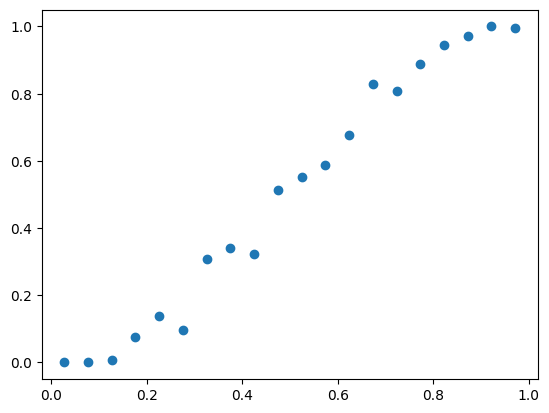

In [126]:
Pb_YgX, P_RgX = psychometric_choice_probability(trials_df,trials_df['post_prob_pos'],n_bins=20)
plt.plot(Pb_YgX, P_RgX, 'o')

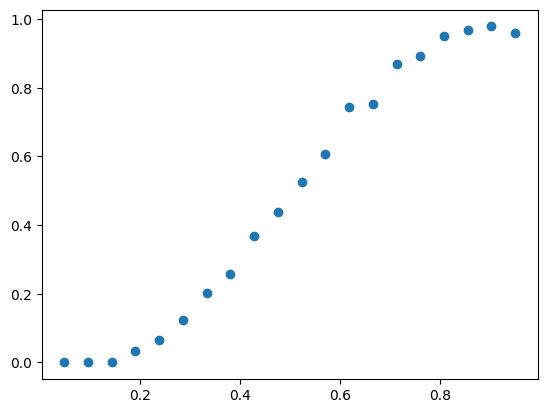

In [127]:
Pb_YgX_1b, P_RgX_1b = psychometric_choice_probability(trials_df,trials_df['post_prob_1b_pos'],n_bins=20)
plt.plot(Pb_YgX_1b, P_RgX_1b, 'o')

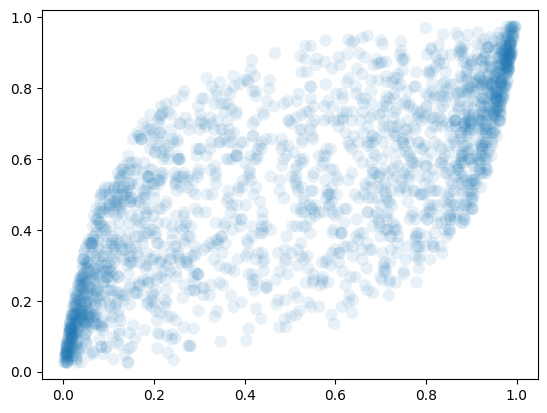

In [125]:
plt.scatter(trials_df['post_prob_pos'], trials_df['post_prob_1b_pos'], s=80,alpha=0.1, edgecolor='none')

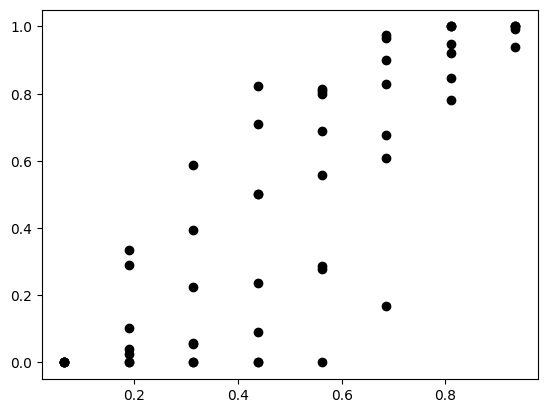

In [136]:
P_YgX_2d, P_RgX_2d = psychometric_choice_probability_2d(trials_df, ("post_prob_pos", "post_prob_1b_pos"), n_bins=8)
plt.plot(P_YgX_2d[:,:,0],P_RgX_2d,'ok')

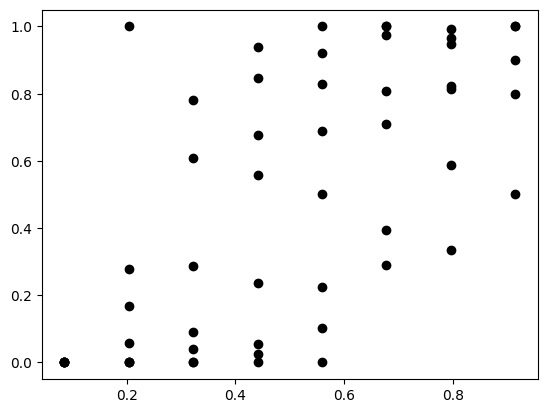

In [137]:
plt.plot(P_YgX_2d[:,:,1],P_RgX_2d,'ok')

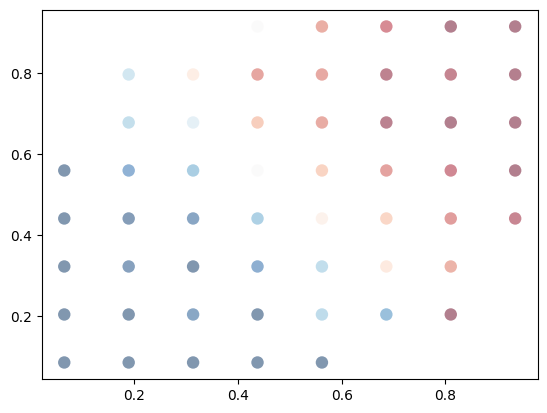

In [142]:
plt.scatter(P_YgX_2d[:,:,0].flatten(),P_YgX_2d[:,:,1].flatten(),s=80,alpha=0.5, edgecolor='none', c=P_RgX_2d.flatten(), cmap='RdBu_r')

In [135]:
P_YgX_2d[:,:,0]

array([[0.0645604 , 0.0645604 , 0.0645604 , 0.0645604 , 0.0645604 ,
        0.0645604 , 0.0645604 , 0.0645604 ],
       [0.18884438, 0.18884438, 0.18884438, 0.18884438, 0.18884438,
        0.18884438, 0.18884438, 0.18884438],
       [0.31312837, 0.31312837, 0.31312837, 0.31312837, 0.31312837,
        0.31312837, 0.31312837, 0.31312837],
       [0.43741235, 0.43741235, 0.43741235, 0.43741235, 0.43741235,
        0.43741235, 0.43741235, 0.43741235],
       [0.56169633, 0.56169633, 0.56169633, 0.56169633, 0.56169633,
        0.56169633, 0.56169633, 0.56169633],
       [0.68598031, 0.68598031, 0.68598031, 0.68598031, 0.68598031,
        0.68598031, 0.68598031, 0.68598031],
       [0.8102643 , 0.8102643 , 0.8102643 , 0.8102643 , 0.8102643 ,
        0.8102643 , 0.8102643 , 0.8102643 ],
       [0.93454828, 0.93454828, 0.93454828, 0.93454828, 0.93454828,
        0.93454828, 0.93454828, 0.93454828]])

In [107]:
from scipy.special import logit
trials_df['LPO_pos'] = logit(trials_df['post_prob_pos'])
trials_df['LPO_1b_pos'] = logit(trials_df['post_prob_1b_pos'])
trials_df[["block_id", "trial", "LPO_pos", "LPO_1b_pos"]].head()

,block_id,trial,LPO_pos,LPO_1b_pos
0,DCB_S1_B1,1,2.214082,0.768133
1,DCB_S1_B1,2,-1.295317,0.161712
2,DCB_S1_B1,3,-0.875250,0.444709
3,DCB_S1_B1,4,2.111204,1.172414
4,DCB_S1_B1,5,4.013534,1.900119


array([[<Axes: title={'center': 'post_prob_pos'}>]], dtype=object)

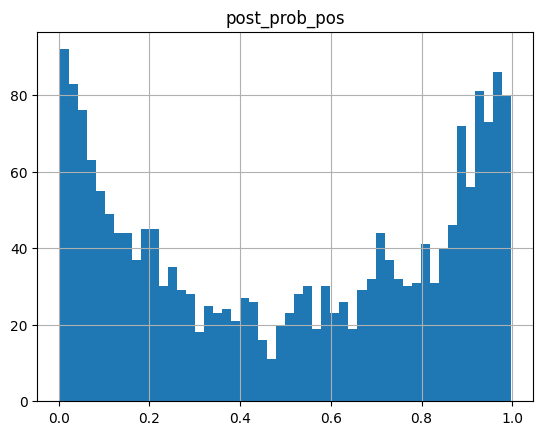

In [103]:
trials_df.hist(column="post_prob_pos", bins=50)

array([[<Axes: title={'center': 'post_prob_1b_pos'}>]], dtype=object)

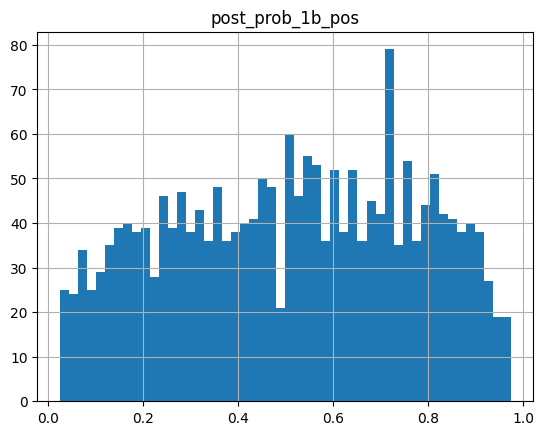

In [106]:
trials_df.hist(column="post_prob_1b_pos", bins=50)

(array([ 1.,  2.,  1.,  4.,  6., 15., 10., 17., 21., 20., 37., 25., 46.,
        43., 48., 52., 54., 60., 66., 77., 77., 64., 61., 61., 68., 53.,
        73., 74., 73., 87., 68., 70., 55., 61., 83., 56., 69., 43., 41.,
        44., 25., 22., 27., 19., 13.,  6.,  3.,  0.,  2.,  2.]),
 array([-6.0222237 , -5.78762776, -5.55303182, -5.31843587, -5.08383993,
        -4.84924399, -4.61464805, -4.3800521 , -4.14545616, -3.91086022,
        -3.67626427, -3.44166833, -3.20707239, -2.97247645, -2.7378805 ,
        -2.50328456, -2.26868862, -2.03409268, -1.79949673, -1.56490079,
        -1.33030485, -1.0957089 , -0.86111296, -0.62651702, -0.39192108,
        -0.15732513,  0.07727081,  0.31186675,  0.5464627 ,  0.78105864,
         1.01565458,  1.25025052,  1.48484647,  1.71944241,  1.95403835,
         2.18863429,  2.42323024,  2.65782618,  2.89242212,  3.12701807,
         3.36161401,  3.59620995,  3.83080589,  4.06540184,  4.29999778,
         4.53459372,  4.76918966,  5.00378561,  5.23838155,

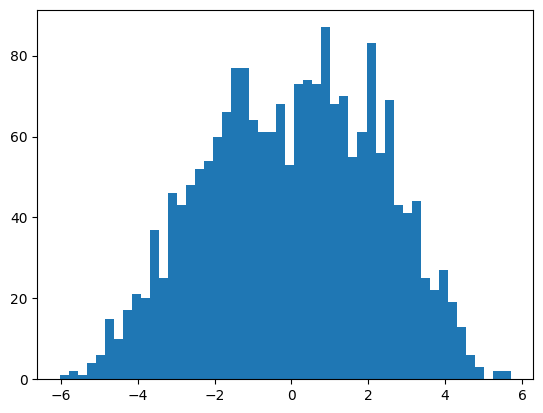

In [105]:
from scipy.special import logit
plt.hist(logit(trials_df["post_prob_pos"]), bins=50)

In [73]:
def P_source_g_samples_alt(LLR_arr,h,L0):
    L = L0
    for ii in range(len(LLR_arr)):
        L = (L + np.log((1-h)/h + np.exp(-L)) - np.log((1-h)/h + np.exp(L))) + LLR_arr[ii]
    p = np.exp(L) / (1+np.exp(L))
    P = np.stack((1-p,p),axis=0).reshape(-1,1)
    return P

<Axes: >

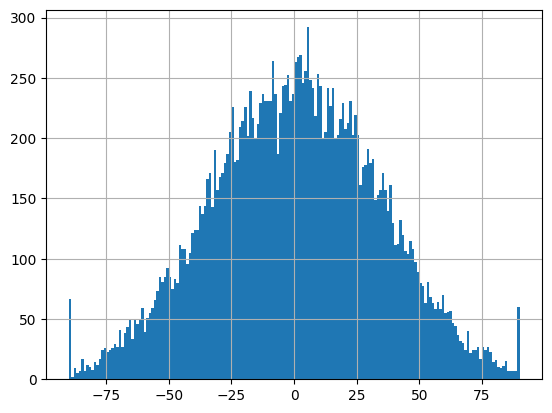

In [40]:
samples_df['stim_location_deg'].hist(bins=np.arange(-90, 91, 1))

In [39]:
samples_df['stim_location_deg'].describe()

count    21349.000000
mean         0.006839
std         33.445009
min        -90.000000
25%        -23.000000
50%          0.000000
75%         23.000000
max         90.000000
Name: stim_location_deg, dtype: float64

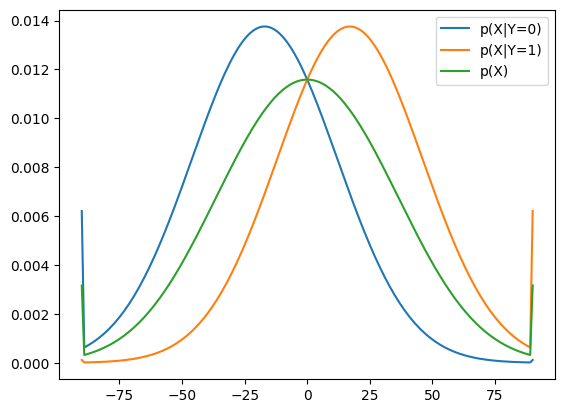

In [12]:
from scipy.stats import norm
from torch import var

mean0, mean1 = -17, 17
std = 29

X = np.arange(-90, 91)
p_XgY0 = np.zeros(181)
p_XgY1 = np.zeros(181)

p_XgY0[0] = norm.cdf(-90.5,loc=mean0,scale=std)
p_XgY1[0] = norm.cdf(-90.5,loc=mean1,scale=std)

p_XgY0[-1] = 1 - norm.cdf(90.5,loc=mean0,scale=std)
p_XgY1[-1] = 1 - norm.cdf(90.5,loc=mean1,scale=std)
for i in range(181):
    p_XgY0[i] += norm.cdf(X[i]+0.5,loc=mean0,scale=std) - norm.cdf(X[i]-0.5,loc=mean0,scale=std)
    p_XgY1[i] += norm.cdf(X[i]+0.5,loc=mean1,scale=std) - norm.cdf(X[i]-0.5,loc=mean1,scale=std)

p_X = 0.5 * p_XgY0 + 0.5 * p_XgY1

import matplotlib.pyplot as plt
plt.plot(X, p_XgY0, label="p(X|Y=0)")
plt.plot(X, p_XgY1, label="p(X|Y=1)")
plt.plot(X, p_X, label="p(X)")
plt.legend()
plt.show()

In [50]:
np.log(p_XgY1[-1] / p_XgY0[-1])

3.945245272349476

In [25]:
conds = (samples_df['session']==1) & (samples_df['block']==1) & (samples_df['trial']==7)
samples_df.loc[conds, 'stim_location_deg']

72   -22.0
73    49.0
74   -45.0
75     7.0
76   -12.0
77    33.0
78   -25.0
79    19.0
80    12.0
81   -44.0
82   -54.0
83    -9.0
Name: stim_location_deg, dtype: float64

In [35]:
non_whole_stim_values = samples_df.loc[
    samples_df["stim_location_deg"].notna()
    & ~np.isclose(samples_df["stim_location_deg"], np.round(samples_df["stim_location_deg"])),
    "stim_location_deg",
]

non_whole_stim_values.unique()

array([ 89.99, -89.99])

In [26]:
samples_df.loc[samples_df['stim_location_deg']>89, 'stim_location_deg']

466      89.99
584      89.99
983      89.99
1473     89.99
2350     89.99
2714     89.99
2774     89.99
3536     89.99
3601     89.99
3866     89.99
4855     89.99
5184     89.99
6103     89.99
7010     89.99
9715     89.99
9865     89.99
10197    89.99
10397    89.99
10982    89.99
11575    89.99
11594    89.99
12196    89.99
12564    89.99
12993    89.99
13122    89.99
13414    89.99
13834    89.99
14211    89.99
14468    89.99
15547    89.99
15997    89.99
16061    89.99
16552    89.99
17490    89.99
17654    89.99
17891    89.99
17896    89.99
18430    89.99
18539    89.99
19062    89.99
19658    89.99
19730    89.99
19759    89.99
19910    89.99
19912    89.99
19926    89.99
20443    89.99
20866    89.99
21835    89.99
21944    89.99
22584    89.99
22670    89.99
23558    89.99
23607    89.99
23849    89.99
Name: stim_location_deg, dtype: float64

In [27]:
samples_df.loc[samples_df['stim_location_deg']<-89, 'stim_location_deg']

599     -89.99
641     -89.99
649     -89.99
1273    -89.99
1565    -89.99
         ...  
21955   -89.99
22059   -89.99
22816   -89.99
23335   -89.99
23650   -89.99
Name: stim_location_deg, Length: 67, dtype: float64

In [28]:
trials_df

,block_id,subject_folder,participant_id,session_label,session,block,trial,correct_response_dist,response,accuracy,rt_from_go_cue,trial_onset_ptb,fixation_break_count,n_presented_samples,final_sample_location
0,DCB_S1_B1,DCB,DCB,S1,1,1,1,1.0,1.0,1.0,1.515773,1.497944e+09,0.0,8,19.0
1,DCB_S1_B1,DCB,DCB,S1,1,1,2,2.0,2.0,1.0,0.007256,1.497944e+09,0.0,12,4.0
2,DCB_S1_B1,DCB,DCB,S1,1,1,3,2.0,1.0,0.0,0.006124,1.497944e+09,0.0,12,11.0
3,DCB_S1_B1,DCB,DCB,S1,1,1,4,1.0,1.0,1.0,0.006226,1.497944e+09,0.0,12,29.0
4,DCB_S1_B1,DCB,DCB,S1,1,1,5,1.0,1.0,1.0,0.006103,1.497944e+09,0.0,4,47.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2000,DCB_S3_B9,DCB,DCB,S3,3,9,72,1.0,2.0,0.0,0.006108,1.498124e+09,0.0,12,-44.0
2001,DCB_S3_B9,DCB,DCB,S3,3,9,73,2.0,1.0,0.0,0.006171,1.498125e+09,0.0,3,41.0
2002,DCB_S3_B9,DCB,DCB,S3,3,9,74,1.0,1.0,1.0,0.006191,1.498125e+09,0.0,12,19.0
2003,DCB_S3_B9,DCB,DCB,S3,3,9,75,1.0,1.0,1.0,0.006103,1.498125e+09,0.0,12,19.0


In [41]:
samples_arr_by_trial = (
    samples_df.sort_values("sample")
    .groupby(["session", "block", "trial"])["stim_location_deg"]
    .apply(lambda s: s.dropna().to_numpy())
)

trials_df["samples_arr"] = pd.MultiIndex.from_frame(
    trials_df[["session", "block", "trial"]]
).map(samples_arr_by_trial)

trials_df[["session", "block", "trial", "n_presented_samples", "samples_arr"]].head()

,session,block,trial,n_presented_samples,samples_arr
0,1,1,1,8,"[61.0, -38.0, 81.0, 7.0, -37.0, 28.0, 20.0, 19.0]"
1,1,1,2,12,"[-67.0, -35.0, -8.0, -34.0, -61.0, 6.0, -29.0,..."
2,1,1,3,12,"[23.0, -25.0, -17.0, -25.0, 5.0, 1.0, -5.0, -2..."
3,1,1,4,12,"[-1.0, 67.0, -14.0, 0.0, 9.0, -10.0, 50.0, -32..."
4,1,1,5,4,"[56.0, 5.0, 48.0, 47.0]"


In [42]:
samples_df[24:36]

,block_id,subject_folder,participant_id,session_label,session,block,trial,sample,stim_location_deg,generative_dist,distribution_switch,sample_onset_from_trial_s
24,DCB_S1_B1,DCB,DCB,S1,1,1,3,1,23.0,1.0,0.0,0.399986
25,DCB_S1_B1,DCB,DCB,S1,1,1,3,2,-25.0,1.0,0.0,0.799969
26,DCB_S1_B1,DCB,DCB,S1,1,1,3,3,-17.0,1.0,0.0,1.199956
27,DCB_S1_B1,DCB,DCB,S1,1,1,3,4,-25.0,1.0,0.0,1.599941
28,DCB_S1_B1,DCB,DCB,S1,1,1,3,5,5.0,1.0,0.0,1.999928
29,DCB_S1_B1,DCB,DCB,S1,1,1,3,6,1.0,1.0,0.0,2.399905
30,DCB_S1_B1,DCB,DCB,S1,1,1,3,7,-5.0,1.0,0.0,2.799891
31,DCB_S1_B1,DCB,DCB,S1,1,1,3,8,-29.0,1.0,0.0,3.199878
32,DCB_S1_B1,DCB,DCB,S1,1,1,3,9,-48.0,1.0,0.0,3.599864
33,DCB_S1_B1,DCB,DCB,S1,1,1,3,10,31.0,1.0,0.0,3.999851


In [34]:
trials_df[["session", "block", "trial", "n_presented_samples", "samples_arr"]][100]

KeyError: 100

In [13]:
np.sum(samples_df['stim_location_deg'] == 0)

263

In [14]:
2**9

512

In [15]:
4**5

1024